# Time Series Analysis: ESN Porto Student Registrations

**Group 26**
- Adriano Machado
- Francisco da Ana
- João Lopes
- Tiago Teixeira

This analysis examines ESN (Erasmus Student Network) card registration patterns from international students in Porto, spanning academic years 2020-2021 through 2025-2026. The data captures the moment students activate their ESN membership, allowing the analysis of international student arrival dynamics.

The dataset comes from ESN Porto's administrative records of ESNcard activations. The ESNcard is a membership card that international students typically purchase when they arrive in Porto, giving them access to various discounts and benefits. The data primarily reflects Erasmus and other exchange students studying at Porto's universities.

## 1. Setup & Data Loading

In [23]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy import stats
from scipy.stats import chi2_contingency, normaltest, mannwhitneyu
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from collections import Counter
import re

from matplotlib.gridspec import GridSpec

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

In [24]:
data_dir = Path('data')
files = sorted(data_dir.glob('students_*_privatized.json'))

all_students = []
metadata_by_year = {}

for file in files:
    year = file.stem.split('_')[1]  
    
    with open(file, 'r') as f:
        data = json.load(f)
    
    metadata_by_year[year] = {
        'newStudents': data.get('newStudents', 0),
        'validStudents': data.get('validStudents', 0),
        'sales': data.get('sales', 0),
        'pendingCards': data.get('pendingCards', 0),
        'pendingPurchases': data.get('pendingPurchases', 0)
    }
    
    for student in data.get('students', []):
        student['academic_year'] = year
        all_students.append(student)

df = pd.DataFrame(all_students)

df_metadata = pd.DataFrame(metadata_by_year).T
df_metadata.index.name = 'academic_year'

print(f"Loaded {len(files)} files")
print(f"Total students: {len(df):,}")
print(f"Academic years: {sorted(df['academic_year'].unique())}")

Loaded 6 files
Total students: 14,555
Academic years: ['2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025', '2025-2026']


## 2. Preprocessing & Feature Engineering

We'll create several new features that help us understand the temporal patterns and student characteristics better:

**Date Processing:**
- Converting timestamps into datetime
- Calculating student ages at the time they registered (for spotting age trends)

**Temporal Features:**
- Breaking down registration dates into year, month, quarter, day of week.
- Creating an academic semester indicator (Fall vs Spring) since student arrivals follow academic calendars

**Categorical Features:**
- Grouping programs into broader categories (Erasmus, Volunteer, Exchange, Other)
- Extracting university abbreviations from full names for easier visualization
- Creating an international student flag (non-Portuguese students)

In [25]:
df['birthdate_dt'] = pd.to_datetime(df['birthdate'], unit='ms', errors='coerce')
df['registerDate_dt'] = pd.to_datetime(df['registerDate'], unit='ms', errors='coerce')

df['age_at_registration'] = (df['registerDate_dt'] - df['birthdate_dt']).dt.days / 365.25

df['register_year'] = df['registerDate_dt'].dt.year
df['register_month'] = df['registerDate_dt'].dt.month
df['register_quarter'] = df['registerDate_dt'].dt.quarter
df['register_weekday'] = df['registerDate_dt'].dt.dayofweek
df['register_day'] = df['registerDate_dt'].dt.day

df['register_month_name'] = df['registerDate_dt'].dt.strftime('%B')

df['birth_year'] = df['birthdate_dt'].dt.year
current_date = datetime.now()
df['current_age'] = (current_date - df['birthdate_dt']).dt.days / 365.25

df['program_category'] = df['program'].apply(lambda x: 
    'Erasmus' if 'Erasmus' in str(x) else
    'Volunteer' if 'Volunteer' in str(x) or 'Buddy' in str(x) or 'Alumni' in str(x) else
    'Exchange' if 'exchange' in str(x).lower() else
    'Other'
)

df['university_short'] = df['university'].apply(lambda x: 
    re.search(r'\((\w+)\)', str(x)).group(1) if re.search(r'\((\w+)\)', str(x)) else str(x)
)

df['is_international'] = (df['country'] != 'Portugal').astype(int)

df['academic_semester'] = df['register_month'].apply(lambda x: 
    'Fall' if x in [9, 10, 11, 12, 1] else 'Spring'
)

print("Feature engineering completed")
print(f"\nDataframe shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Feature engineering completed

Dataframe shape: (14555, 26)
Columns: ['gender', 'birthdate', 'address', 'country', 'organization', 'university', 'registerDate', '__v', 'academic_year', 'program', 'programDuration', 'birthdate_dt', 'registerDate_dt', 'age_at_registration', 'register_year', 'register_month', 'register_quarter', 'register_weekday', 'register_day', 'register_month_name', 'birth_year', 'current_age', 'program_category', 'university_short', 'is_international', 'academic_semester']


## 3. Data Quality Assessment

In [26]:
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percent': (df.isnull().sum().values / len(df) * 100).round(2)
}).sort_values('Missing_Count', ascending=False)

print("\n")
print("Missing Values")
print("\n")
print(missing_summary[missing_summary['Missing_Count'] > 0])
print(f"\nColumns with no missing values: {len(missing_summary[missing_summary['Missing_Count'] == 0])}")



Missing Values


                 Column  Missing_Count  Missing_Percent
9               program              4             0.03
10      programDuration              4             0.03
21          current_age              1             0.01
13  age_at_registration              1             0.01
11         birthdate_dt              1             0.01
20           birth_year              1             0.01

Columns with no missing values: 20



The dataset only has 4 missing values (0.03%) in `program` and `programDuration` fields. All temporal and demographic features are complete, so there's no need for data imputation.

In [27]:
quality_checks = {
    'Total Records': len(df),
    'Complete Records': len(df.dropna()),
    'Duplicate Rows': df.duplicated().sum(),
    'Invalid Ages (< 15 or > 100)': ((df['age_at_registration'] < 15) | (df['age_at_registration'] > 100)).sum(),
    'Future Registration Dates': (df['registerDate_dt'] > current_date).sum(),
    'Future Birth Dates': (df['birthdate_dt'] > current_date).sum(),
    'Registration Before Birth': (df['registerDate_dt'] < df['birthdate_dt']).sum(),
    'Missing Gender': df['gender'].isnull().sum(),
    'Missing Country': df['country'].isnull().sum(),
}

print("\n")
print("Data Quality Checks")
print("\n")
for check, value in quality_checks.items():
    print(f"{check}: {value:,}")



Data Quality Checks


Total Records: 14,555
Complete Records: 14,550
Duplicate Rows: 0
Invalid Ages (< 15 or > 100): 28
Future Registration Dates: 0
Future Birth Dates: 2
Registration Before Birth: 16
Missing Gender: 0
Missing Country: 0


The dataset shows high overall quality with 99.97% complete records (14,550 out of 14,555). However, some inconsistencies require attention:

- **46 records with date anomalies**: 28 invalid ages, 2 future birthdates, and 16 registrations predating birth
- **No structural issues**: Zero duplicates, and all critical fields (gender, country) are populated

These anomalies represent 0.32% of the dataset and should be excluded from age-dependent analyses to ensure validity.

In [28]:

print(f"Original dataset size: {len(df)}")

# Remove invalid ages (< 15 or > 100)
df_clean = df[(df['current_age'] >= 15) & (df['current_age'] <= 100)].copy()
print(f"After removing invalid ages: {len(df_clean)} ({len(df) - len(df_clean)} removed)")

# Remove future birth dates
df_clean = df_clean[df_clean['birthdate_dt'] <= pd.Timestamp.now()].copy()
print(f"After removing future birthdates: {len(df_clean)} ({len(df) - len(df_clean)} removed)")

# Remove registrations before birth
df_clean = df_clean[df_clean['registerDate_dt'] >= df_clean['birthdate_dt']].copy()
print(f"After removing registrations before birth: {len(df_clean)} ({len(df) - len(df_clean)} removed)")

print(f"\nFinal clean dataset: {len(df_clean)} records ({(len(df_clean)/len(df)*100):.2f}% retained)")
print(f"Total records removed: {len(df) - len(df_clean)} ({((len(df) - len(df_clean))/len(df)*100):.2f}%)")

df = df_clean.copy()

Original dataset size: 14555
After removing invalid ages: 14526 (29 removed)
After removing future birthdates: 14526 (29 removed)
After removing registrations before birth: 14526 (29 removed)

Final clean dataset: 14526 records (99.80% retained)
Total records removed: 29 (0.20%)


## 4. Univariate Analysis

### 4.1 Demographic Distributions

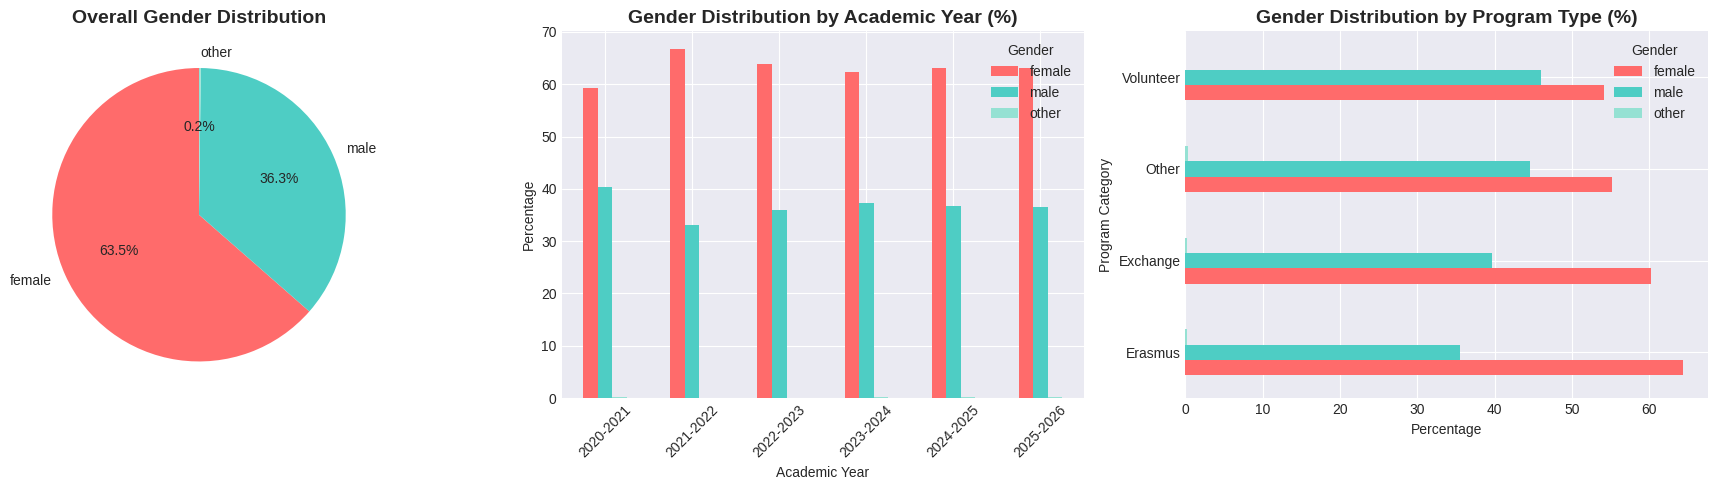

Gender ratio (F:M): 1.75:1


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall gender distribution
gender_counts = df['gender'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#95E1D3']
axes[0].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[0].set_title('Overall Gender Distribution', fontsize=14, fontweight='bold')

# Gender distribution by academic year
gender_by_year = pd.crosstab(df['academic_year'], df['gender'], normalize='index') * 100
gender_by_year.plot(kind='bar', ax=axes[1], color=colors[:len(gender_by_year.columns)])
axes[1].set_title('Gender Distribution by Academic Year (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Academic Year')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Gender')
axes[1].tick_params(axis='x', rotation=45)

# Gender distribution by program category
gender_by_program = pd.crosstab(df['program_category'], df['gender'], normalize='index') * 100
gender_by_program.plot(kind='barh', ax=axes[2], color=colors[:len(gender_by_program.columns)])
axes[2].set_title('Gender Distribution by Program Type (%)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Percentage')
axes[2].set_ylabel('Program Category')
axes[2].legend(title='Gender')

plt.tight_layout()
plt.show()

print(f"Gender ratio (F:M): {gender_counts['female']/gender_counts['male']:.2f}:1")

The gender split shows a clear female majority (~64%) that holds remarkably steady across all years and program types. This 1.75:1 ratio is expected as women are also the majority of european university students.

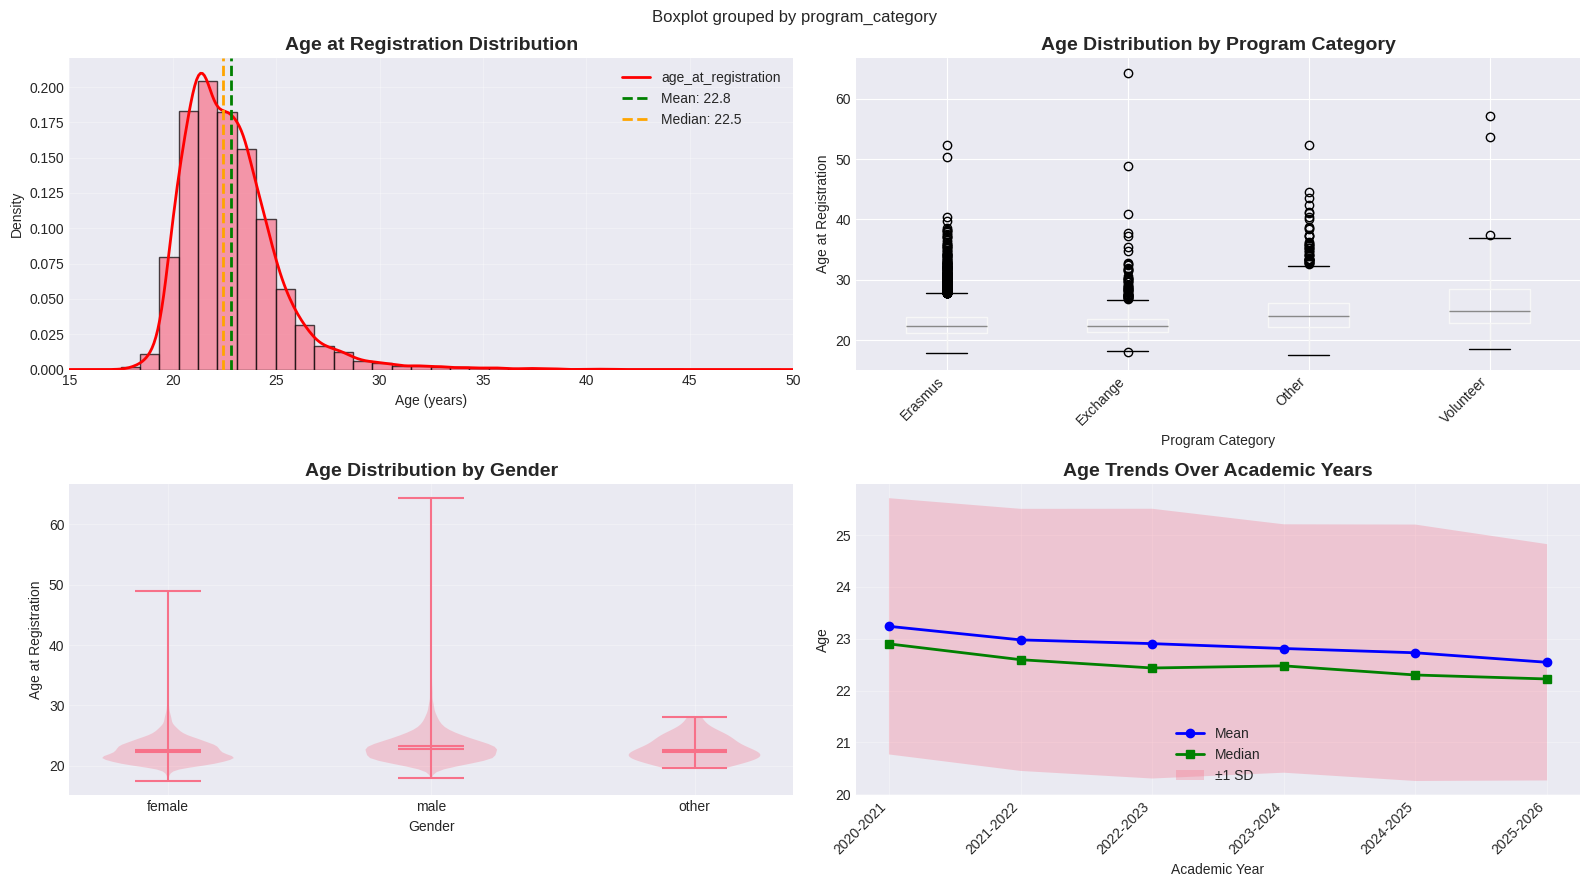

In [30]:
# Age distribution analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# Age at registration - histogram
axes[0, 0].hist(df['age_at_registration'].dropna(), bins=50, edgecolor='black', alpha=0.7, density=True)
df['age_at_registration'].dropna().plot(kind='kde', ax=axes[0, 0], linewidth=2, color='red')
axes[0, 0].axvline(df['age_at_registration'].mean(), color='green', linestyle='--', linewidth=2, label=f"Mean: {df['age_at_registration'].mean():.1f}")
axes[0, 0].axvline(df['age_at_registration'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median: {df['age_at_registration'].median():.1f}")
axes[0, 0].set_title('Age at Registration Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Age (years)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xlim(15, 50)

# Box plot - Age by program category
df.boxplot(column='age_at_registration', by='program_category', ax=axes[0, 1])
axes[0, 1].set_title('Age Distribution by Program Category', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Program Category')
axes[0, 1].set_ylabel('Age at Registration')
plt.sca(axes[0, 1])
plt.xticks(rotation=45, ha='right')

# Violin plot - Age by gender
parts = axes[1, 0].violinplot(
    [df[df['gender'] == g]['age_at_registration'].dropna() for g in df['gender'].unique()],
    positions=range(len(df['gender'].unique())),
    showmeans=True,
    showmedians=True
)
axes[1, 0].set_xticks(range(len(df['gender'].unique())))
axes[1, 0].set_xticklabels(df['gender'].unique())
axes[1, 0].set_title('Age Distribution by Gender', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Gender')
axes[1, 0].set_ylabel('Age at Registration')
axes[1, 0].grid(alpha=0.3)

# Age distribution over time
age_by_year = df.groupby('academic_year')['age_at_registration'].agg(['mean', 'median', 'std'])
x = range(len(age_by_year))
axes[1, 1].plot(x, age_by_year['mean'], marker='o', linewidth=2, label='Mean', color='blue')
axes[1, 1].plot(x, age_by_year['median'], marker='s', linewidth=2, label='Median', color='green')
axes[1, 1].fill_between(x, 
                         age_by_year['mean'] - age_by_year['std'],
                         age_by_year['mean'] + age_by_year['std'],
                         alpha=0.3, label='±1 SD')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(age_by_year.index, rotation=45, ha='right')
axes[1, 1].set_title('Age Trends Over Academic Years', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Academic Year')
axes[1, 1].set_ylabel('Age')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The typical ESN student registers at **22.8 years old** (mean) with a **median of 22.5 years**, following a right-skewed distribution concentrated in the 20-25 age range. Age profiles vary by program: Exchange students trend slightly older (~23-25) than Erasmus students (~22-23), while Volunteer programs show the most diverse age range. Gender differences are minimal. Notably, the mean age has **declined slightly over time** (from ~23 in 2020-2021 to ~22.5 in 2025-2026), though variance remains stable.

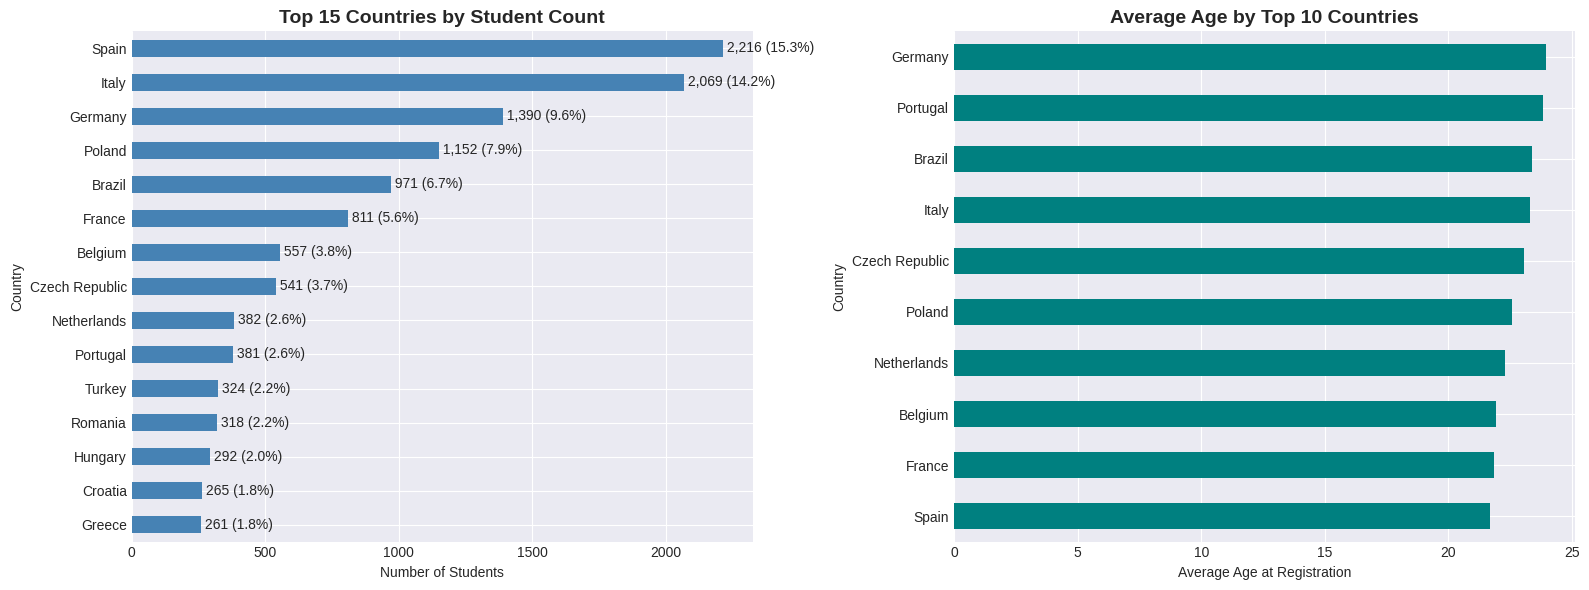

In [31]:
top_n = 15
country_counts = df['country'].value_counts().head(top_n)

top_countries = df['country'].value_counts().head(10).index
age_by_country = df[df['country'].isin(top_countries)].groupby('country')['age_at_registration'].mean().sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

country_counts.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title(f'Top {top_n} Countries by Student Count', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Students')
ax1.set_ylabel('Country')
ax1.invert_yaxis()

total = len(df)
for i, (country, count) in enumerate(country_counts.items()):
    ax1.text(count, i, f' {count:,} ({count/total*100:.1f}%)', va='center')

age_by_country.plot(kind='barh', ax=ax2, color='teal')
ax2.set_title('Average Age by Top 10 Countries', fontsize=14, fontweight='bold')
ax2.set_xlabel('Average Age at Registration')
ax2.set_ylabel('Country')

plt.tight_layout()
plt.show()

The international students are mainly from Southern and Central Europe, with **Spain (15.3%) and Italy (14.2%)** dominating as the top sources, representing nearly 30% of all students. The **top 5 countries** (Spain, Italy, Germany, Poland, Brazil) account for over half of the student body. While European nations predictably lead due to Erasmus programs, **Brazil's strong presence (6.7%)** is a sign of the importance of "intercâmbio" programs.

**German students are the oldest** at registration (avg. ~23.8 years), followed by Portuguese (~23.5) and Brazilian students (~23.3). In contrast, **Spanish and French students are the youngest** (avg. ~22.2 years).

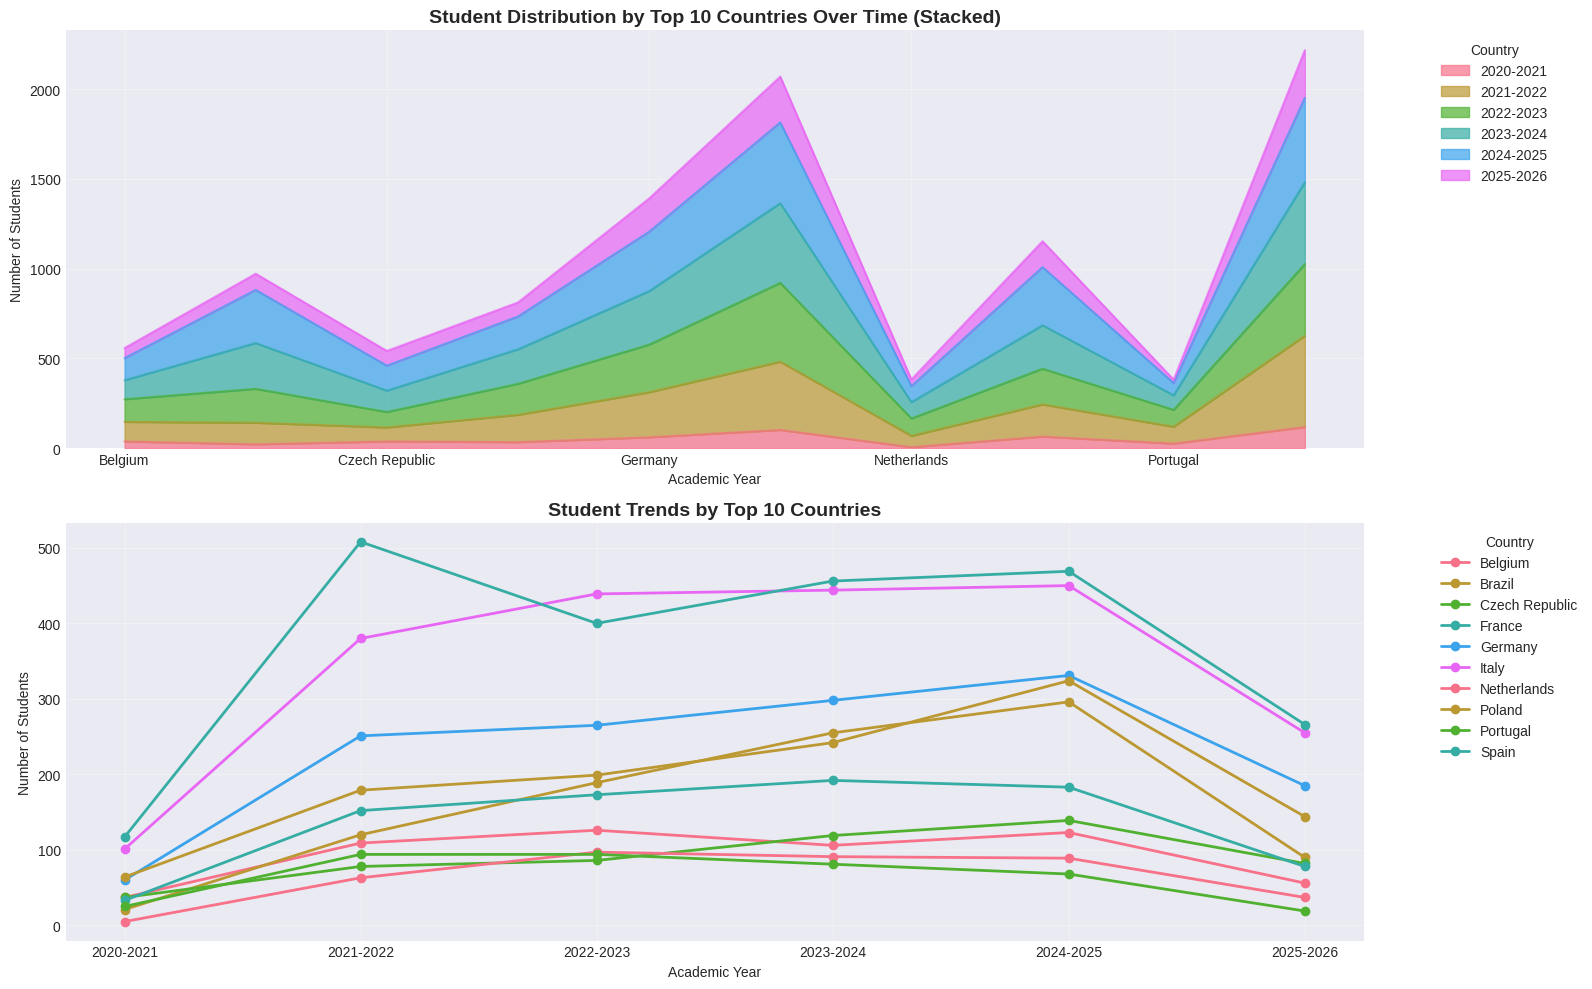

In [32]:
# Top countries analysis with temporal trends
top_10_countries = df['country'].value_counts().head(10).index

country_year = df[df['country'].isin(top_10_countries)].groupby(['academic_year', 'country']).size().unstack(fill_value=0)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Stacked area chart
country_year.T.plot(kind='area', stacked=True, ax=axes[0], alpha=0.7)
axes[0].set_title('Student Distribution by Top 10 Countries Over Time (Stacked)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Academic Year')
axes[0].set_ylabel('Number of Students')
axes[0].legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(alpha=0.3)

# Line chart for each country
country_year.plot(ax=axes[1], marker='o', linewidth=2)
axes[1].set_title('Student Trends by Top 10 Countries', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Academic Year')
axes[1].set_ylabel('Number of Students')
axes[1].legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x')

plt.tight_layout()
plt.show()

In [44]:
# Create seasonal polar plot for student registrations
x = df.groupby(['register_year', 'register_month_name']).size().reset_index(name='registrations')
x['year'] = x['register_year'].astype(str)

# Define month order for proper circular plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

print(f"Min registrations: {x['registrations'].min()}")
print(f"Max registrations: {x['registrations'].max()}")

fig = px.line_polar(x, r='registrations', theta='register_month_name', 
                    color='year', line_close=True, 
                    line_shape='spline', 
                    range_r=[0, x['registrations'].max() * 1.1],
                    color_discrete_sequence=px.colors.qualitative.Plotly,
                    category_orders={'register_month_name': month_order},
                    title='Seasonal Plot: ESN Porto Student Registrations',
                    width=700, height=600)

fig.update_traces(line=dict(width=2.5))
fig.update_layout(
    font=dict(size=12),
    polar=dict(
        radialaxis=dict(
            visible=True,
            gridcolor='lightgray'
        ),
        angularaxis=dict(
            direction='clockwise',
            rotation=90
        )
    )
)

fig.show()

Min registrations: 7
Max registrations: 1543


### 4.2 Academic Patterns

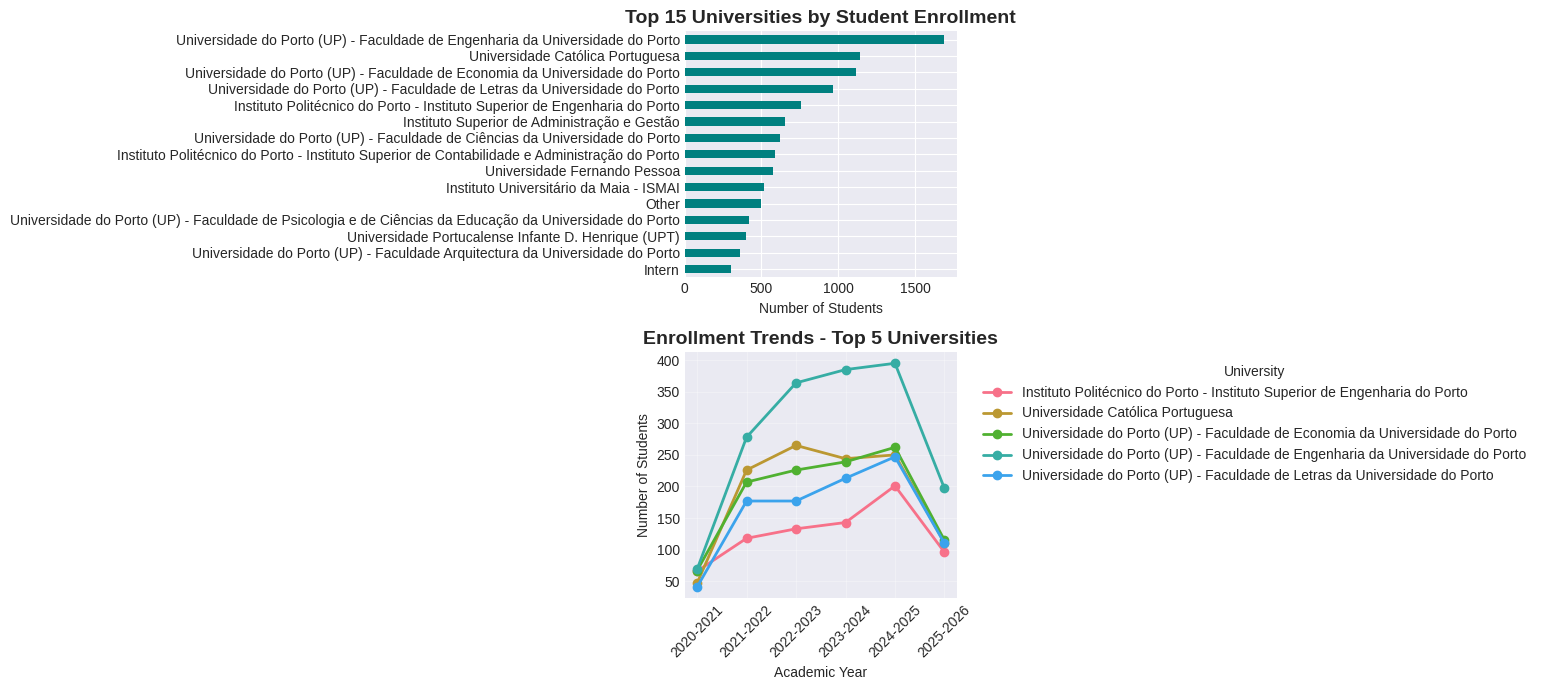

In [33]:
top_universities = df['university'].value_counts().head(15)

fig, axes = plt.subplots(2, 1, figsize=(16, 7))

top_universities.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Top 15 Universities by Student Enrollment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Students')
axes[0].set_ylabel('')
axes[0].invert_yaxis()

top_5_unis = df['university'].value_counts().head(5).index
uni_by_year = df[df['university'].isin(top_5_unis)].groupby(['academic_year', 'university']).size().unstack(fill_value=0)

uni_by_year.plot(kind='line', ax=axes[1], marker='o', linewidth=2)
axes[1].set_title('Enrollment Trends - Top 5 Universities', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Academic Year')
axes[1].set_ylabel('Number of Students')
axes[1].legend(title='University', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The University of Porto leads ESN registrations, with its Faculty of Engineering drawing the largest number of students. From 2020–2021 to 2023–2024, enrollment showed steady growth, peaking at nearly 400 students. The apparent drop in 2024–2025 and 2025–2026 doesn’t indicate a real decline in participation, it simply reflects that this academic year is still ongoing.


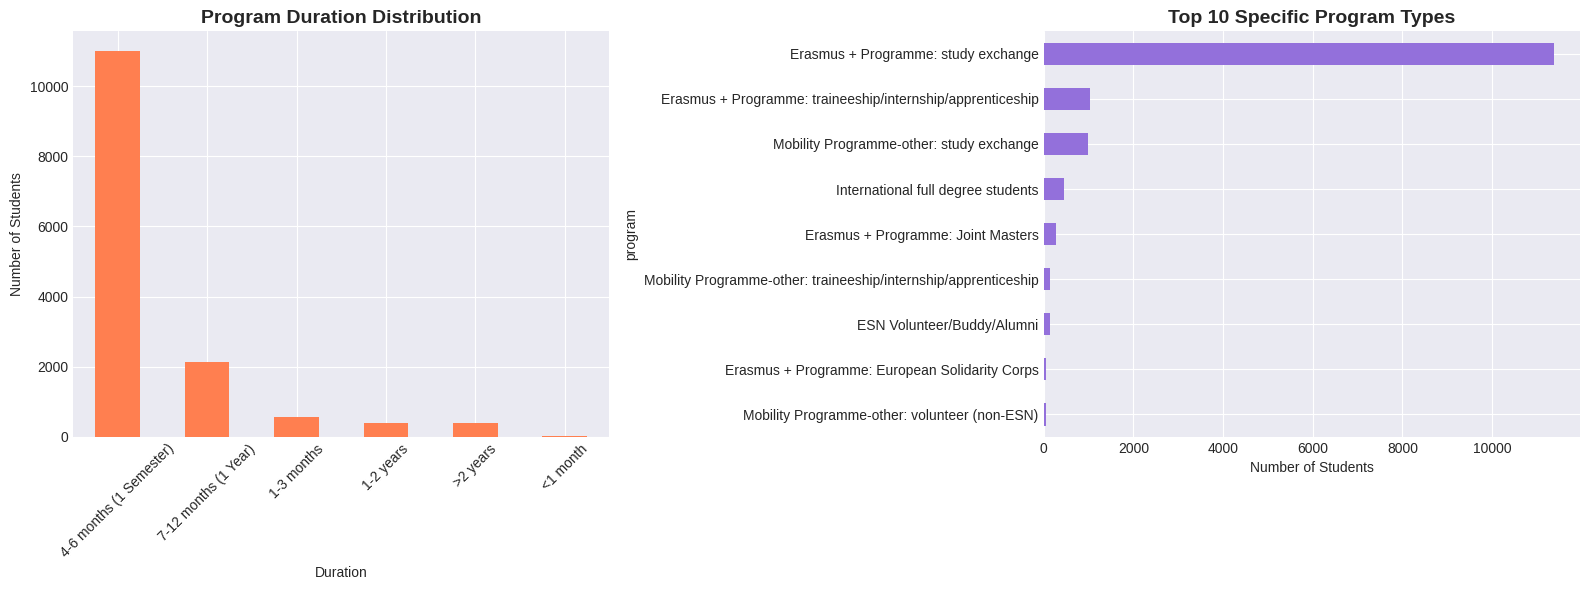

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

duration_counts = df['programDuration'].value_counts()
duration_counts.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Program Duration Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Duration')
axes[0].set_ylabel('Number of Students')
axes[0].tick_params(axis='x', rotation=45)

top_programs = df['program'].value_counts().head(10)
top_programs.plot(kind='barh', ax=axes[1], color='mediumpurple')
axes[1].set_title('Top 10 Specific Program Types', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Students')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 4.3 Temporal Analysis

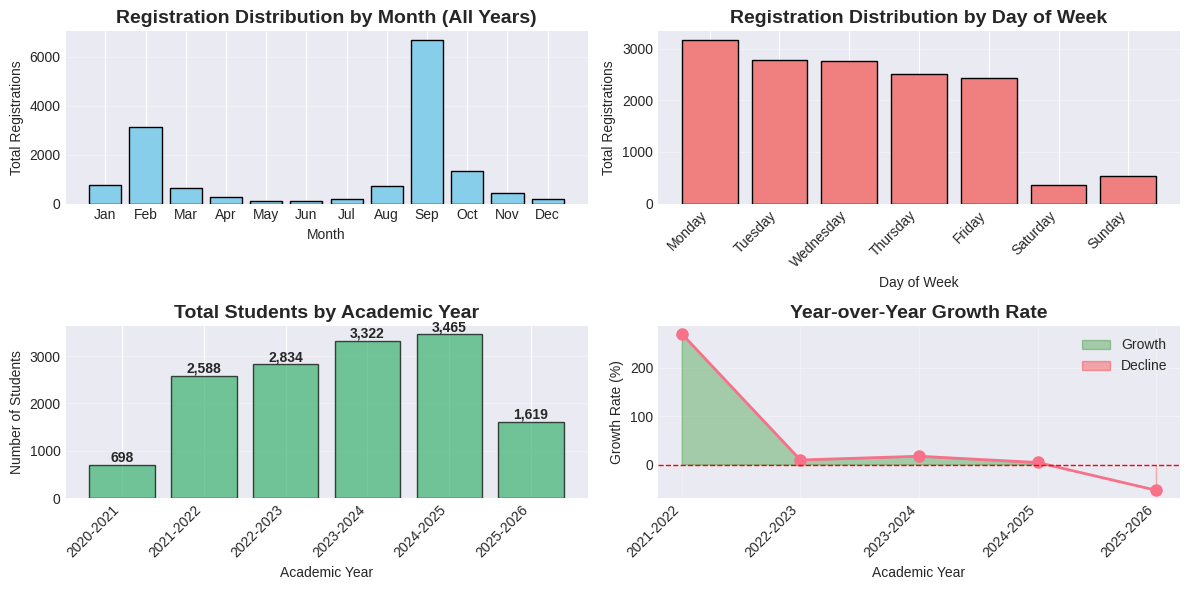

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# Registrations by month (seasonal pattern)
month_dist = df['register_month'].value_counts().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[0, 0].bar(range(1, 13), [month_dist.get(i, 0) for i in range(1, 13)], color='skyblue', edgecolor='black')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(month_names)
axes[0, 0].set_title('Registration Distribution by Month (All Years)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Total Registrations')
axes[0, 0].grid(alpha=0.3, axis='y')

# Registrations by day of week
weekday_dist = df['register_weekday'].value_counts().sort_index()
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
axes[0, 1].bar(range(7), [weekday_dist.get(i, 0) for i in range(7)], color='lightcoral', edgecolor='black')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(weekday_names, rotation=45, ha='right')
axes[0, 1].set_title('Registration Distribution by Day of Week', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Total Registrations')
axes[0, 1].grid(alpha=0.3, axis='y')

# Year-over-year growth
yearly_counts = df['academic_year'].value_counts().sort_index()
yearly_growth = yearly_counts.pct_change() * 100

x = range(len(yearly_counts))
axes[1, 0].bar(x, yearly_counts.values, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(yearly_counts.index, rotation=45, ha='right')
axes[1, 0].set_title('Total Students by Academic Year', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Academic Year')
axes[1, 0].set_ylabel('Number of Students')
axes[1, 0].grid(alpha=0.3, axis='y')

# Add values on bars
for i, v in enumerate(yearly_counts.values):
    axes[1, 0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Growth rate
axes[1, 1].plot(range(1, len(yearly_growth)), yearly_growth.values[1:], marker='o', linewidth=2, markersize=8)
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1, 1].fill_between(range(1, len(yearly_growth)), 0, yearly_growth.values[1:], 
                        where=(yearly_growth.values[1:] > 0), alpha=0.3, color='green', label='Growth')
axes[1, 1].fill_between(range(1, len(yearly_growth)), 0, yearly_growth.values[1:], 
                        where=(yearly_growth.values[1:] <= 0), alpha=0.3, color='red', label='Decline')
axes[1, 1].set_xticks(range(1, len(yearly_growth)))
axes[1, 1].set_xticklabels(yearly_counts.index[1:], rotation=45, ha='right')
axes[1, 1].set_title('Year-over-Year Growth Rate', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Academic Year')
axes[1, 1].set_ylabel('Growth Rate (%)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

ESN registrations peak in September (~6,500) and February (~3,200), aligning with the start of each semester. Most registrations occur on weekdays due to the ESN Porto office being closed. After a sharp rise in 2021 following the easing of COVID restrictions, enrollment continued to grow at a steadier pace. 

## 5. Frequency & Temporal Structure

In [36]:
# Aggregate to daily and monthly series
daily_series = df.groupby(df['registerDate_dt'].dt.date).size()
daily_series.index = pd.to_datetime(daily_series.index)
daily_series.name = 'registrations'

# Create complete daily index (fill gaps with 0)
daily_complete = daily_series.asfreq('D', fill_value=0)

# Monthly aggregation
monthly_series = df.groupby(df['registerDate_dt'].dt.to_period('M')).size()
monthly_series.index = monthly_series.index.to_timestamp()
monthly_series.name = 'registrations'
monthly_complete = monthly_series.asfreq('MS', fill_value=0)

# Weekly aggregation
weekly_series = df.groupby(df['registerDate_dt'].dt.to_period('W')).size()
weekly_series.index = weekly_series.index.to_timestamp()
weekly_series.name = 'registrations'

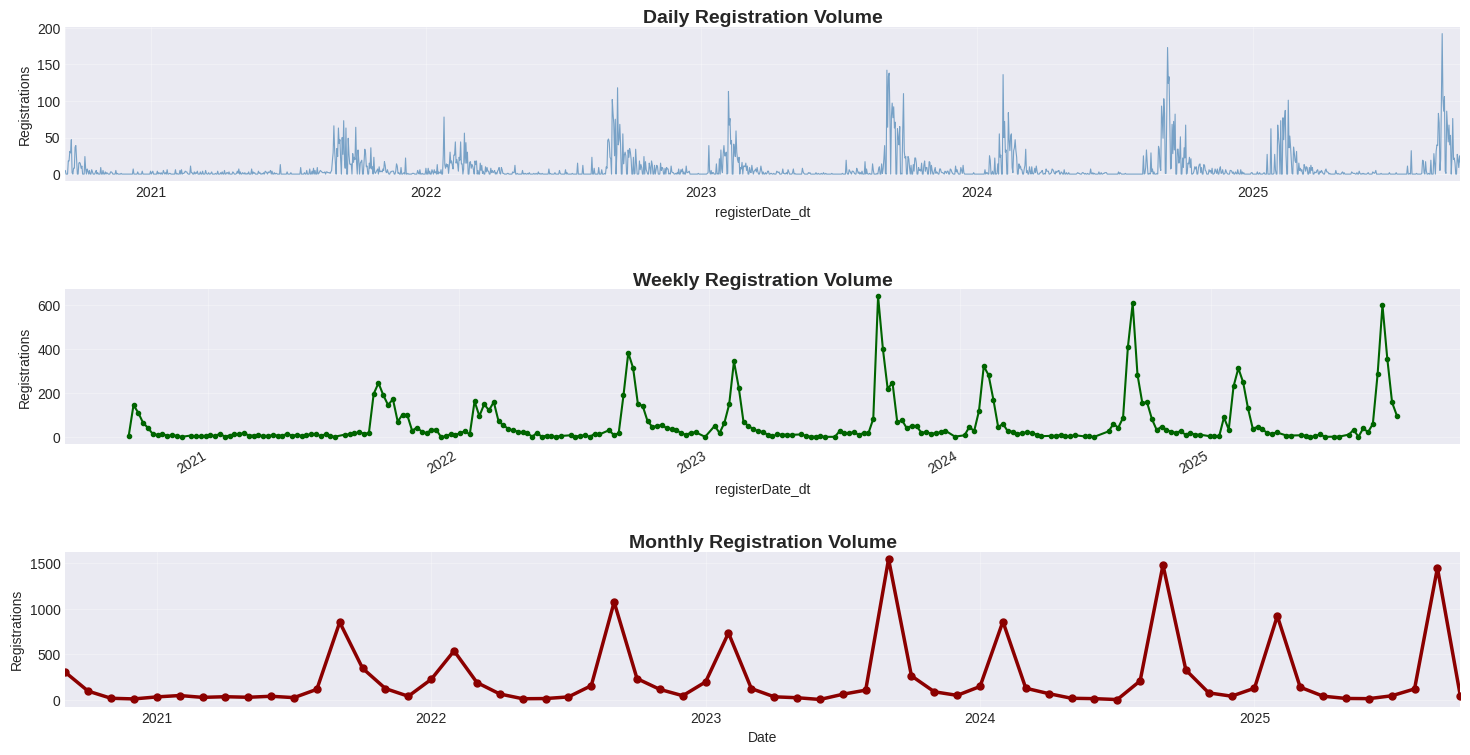

In [37]:
fig = plt.figure(figsize=(18, 10))
gs = GridSpec(3, 1, figure=fig, hspace=0.7)

# Daily
ax1 = fig.add_subplot(gs[0, 0])
daily_complete.plot(ax=ax1, linewidth=0.8, alpha=0.7, color='steelblue')
ax1.set_title('Daily Registration Volume', fontsize=14, fontweight='bold', pad=-20)
ax1.set_ylabel('Registrations')
ax1.grid(alpha=0.3)

# Weekly
ax2 = fig.add_subplot(gs[1, 0])
weekly_series.plot(ax=ax2, linewidth=1.5, color='darkgreen', marker='o', markersize=3)
ax2.set_title('Weekly Registration Volume', fontsize=14, fontweight='bold', pad=-20)
ax2.set_ylabel('Registrations')
ax2.grid(alpha=0.3)

# Monthly
ax3 = fig.add_subplot(gs[2, 0])
monthly_complete.plot(ax=ax3, linewidth=2.5, color='darkred', marker='o', markersize=5)
ax3.set_title('Monthly Registration Volume', fontsize=14, fontweight='bold', pad=-20)
ax3.set_ylabel('Registrations')
ax3.set_xlabel('Date')
ax3.grid(alpha=0.3)

plt.savefig('plots/frequency_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


- **Daily data** shows high-frequency noise with extreme sparsity, most days have zero registrations, with intense bursts during semester starts. 
- **Weekly aggregation** smooths these spikes while preserving the academic calendar's bimodal pattern. 
- **Monthly frequency** provides the clearest signal, showing strong annual seasonality with September peaks (~1,500 registrations) and summer troughs (~100-200).

### 5.1. Trend Analysis

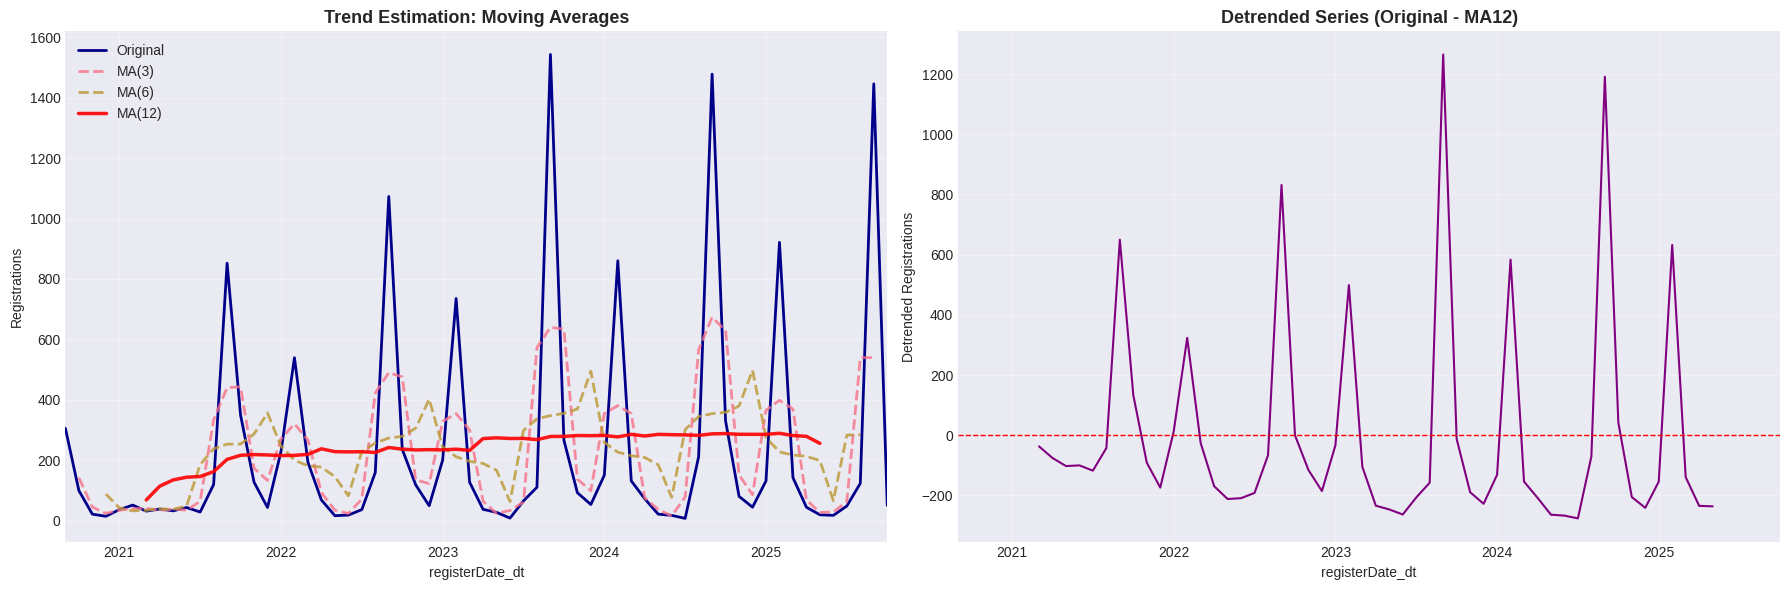

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
monthly_complete.plot(ax=ax, label='Original', linewidth=2, color='darkblue')

ma_3 = monthly_complete.rolling(window=3, center=True).mean()
ma_6 = monthly_complete.rolling(window=6, center=True).mean()
ma_12 = monthly_complete.rolling(window=12, center=True).mean()

ma_3.plot(ax=ax, label='MA(3)', linewidth=2, linestyle='--', alpha=0.8)
ma_6.plot(ax=ax, label='MA(6)', linewidth=2, linestyle='--', alpha=0.8)
ma_12.plot(ax=ax, label='MA(12)', linewidth=2.5, linestyle='-', alpha=0.9, color='red')

ax.set_title('Trend Estimation: Moving Averages', fontsize=13, fontweight='bold')
ax.set_ylabel('Registrations')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

ax = axes[1]
detrended = monthly_complete - ma_12
detrended.plot(ax=ax, linewidth=1.5, color='purple')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax.set_title('Detrended Series (Original - MA12)', fontsize=13, fontweight='bold')
ax.set_ylabel('Detrended Registrations')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/trend_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

The **12-month moving average (MA12)** isolates the long-term trend by smoothing out seasonal fluctuations, revealing a gradual upward trajectory from ~200 to ~300 monthly registrations between 2021-2025. Shorter windows (MA3, MA6) track seasonal variations too closely. 

After removing this trend, the detrended series shows the isolated seasonal component of the data. This series now oscillates around zero, revealing a strong and consistent annual pattern with peaks occurring in the middle of each year and troughs at the beginning of the year. Notably, the magnitude of these seasonal swings appears to be increasing over time, as the peaks in 2023 and 2024 are significantly larger than those in 2021 and 2022.

### 5.2. Seasonality Detection

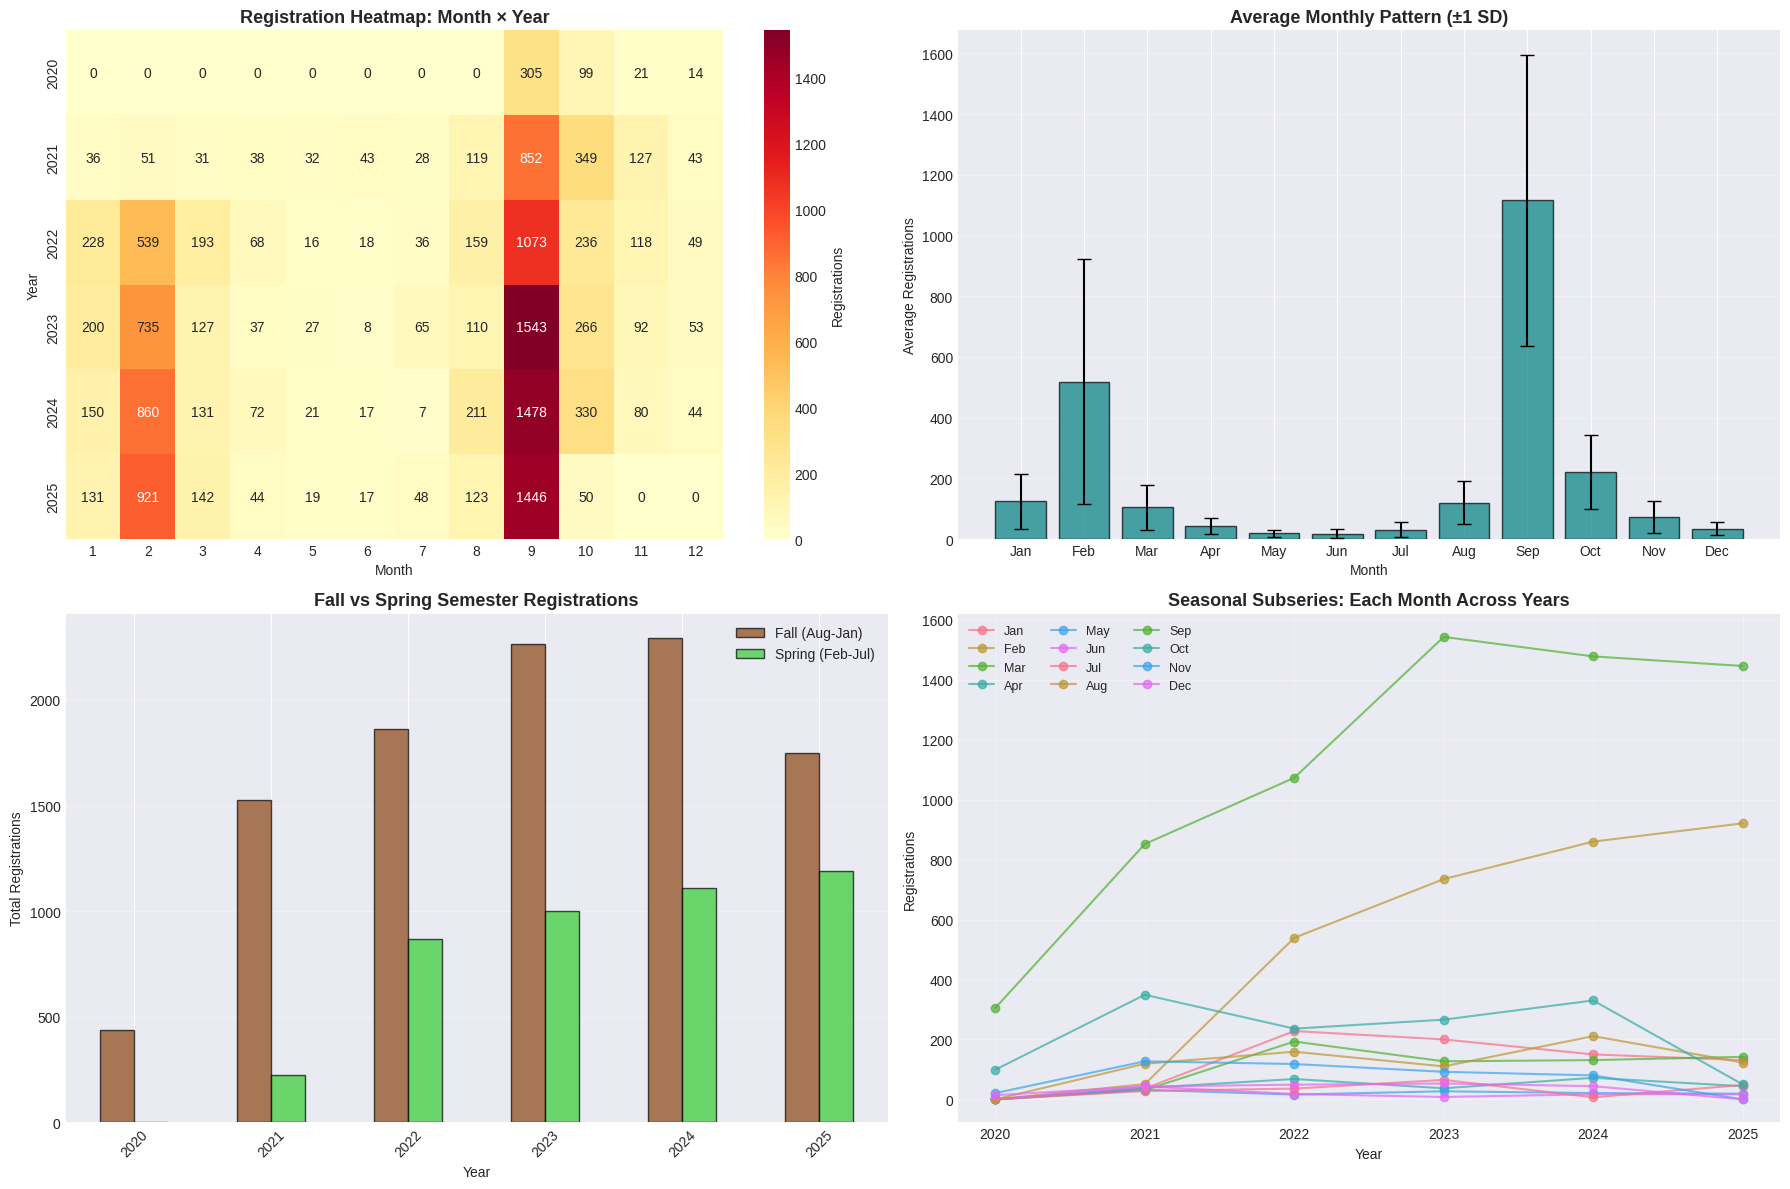

In [39]:
df['month'] = df['registerDate_dt'].dt.month
df['year'] = df['registerDate_dt'].dt.year

monthly_patterns = df.groupby(['year', 'month']).size().unstack(fill_value=0)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

ax = axes[0, 0]
sns.heatmap(monthly_patterns, annot=True, fmt='d', cmap='YlOrRd', 
            ax=ax, cbar_kws={'label': 'Registrations'})
ax.set_title('Registration Heatmap: Month × Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Year')

ax = axes[0, 1]
avg_monthly = monthly_patterns.mean(axis=0)
std_monthly = monthly_patterns.std(axis=0)

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
x = np.arange(1, 13)
ax.bar(x, avg_monthly, yerr=std_monthly, capsize=5, color='teal', alpha=0.7, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(month_names)
ax.set_title('Average Monthly Pattern (±1 SD)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Average Registrations')
ax.grid(alpha=0.3, axis='y')

ax = axes[1, 0]
fall_months = [8, 9, 10, 11, 12, 1]
spring_months = [2, 3, 4, 5, 6, 7]

semester_data = []
for year in monthly_patterns.index:
    fall_total = monthly_patterns.loc[year, fall_months].sum()
    spring_total = monthly_patterns.loc[year, spring_months].sum()
    semester_data.append({'Year': year, 'Fall': fall_total, 'Spring': spring_total})

semester_df = pd.DataFrame(semester_data).set_index('Year')
semester_df.plot(kind='bar', ax=ax, color=['#8B4513', '#32CD32'], edgecolor='black', alpha=0.7)
ax.set_title('Fall vs Spring Semester Registrations', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Registrations')
ax.set_xlabel('Year')
ax.tick_params(axis='x', rotation=45)
ax.legend(['Fall (Aug-Jan)', 'Spring (Feb-Jul)'])
ax.grid(alpha=0.3, axis='y')

ax = axes[1, 1]
for month in range(1, 13):
    month_data = monthly_patterns[month]
    ax.plot(month_data.index, month_data.values, marker='o', label=month_names[month-1], alpha=0.7)

ax.set_title('Seasonal Subseries: Each Month Across Years', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Registrations')
ax.legend(ncol=3, fontsize=9, loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/seasonality_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate seasonality strength
peak_month = avg_monthly.idxmax()
trough_month = avg_monthly.idxmin()
seasonality_ratio = avg_monthly.max() / avg_monthly.mean()

The heatmap shows that September stands out as the peak month for student registrations each year, ranging from about 850 in 2021 to over 1,500 in 2023. On average, The Fall semester consistently draws 60–70% more students than Spring, which aligns with the trend of students beginning full-year exchanges in September. 

### 5.3. Feature Extraction: Seasonal Decomposition (STL)

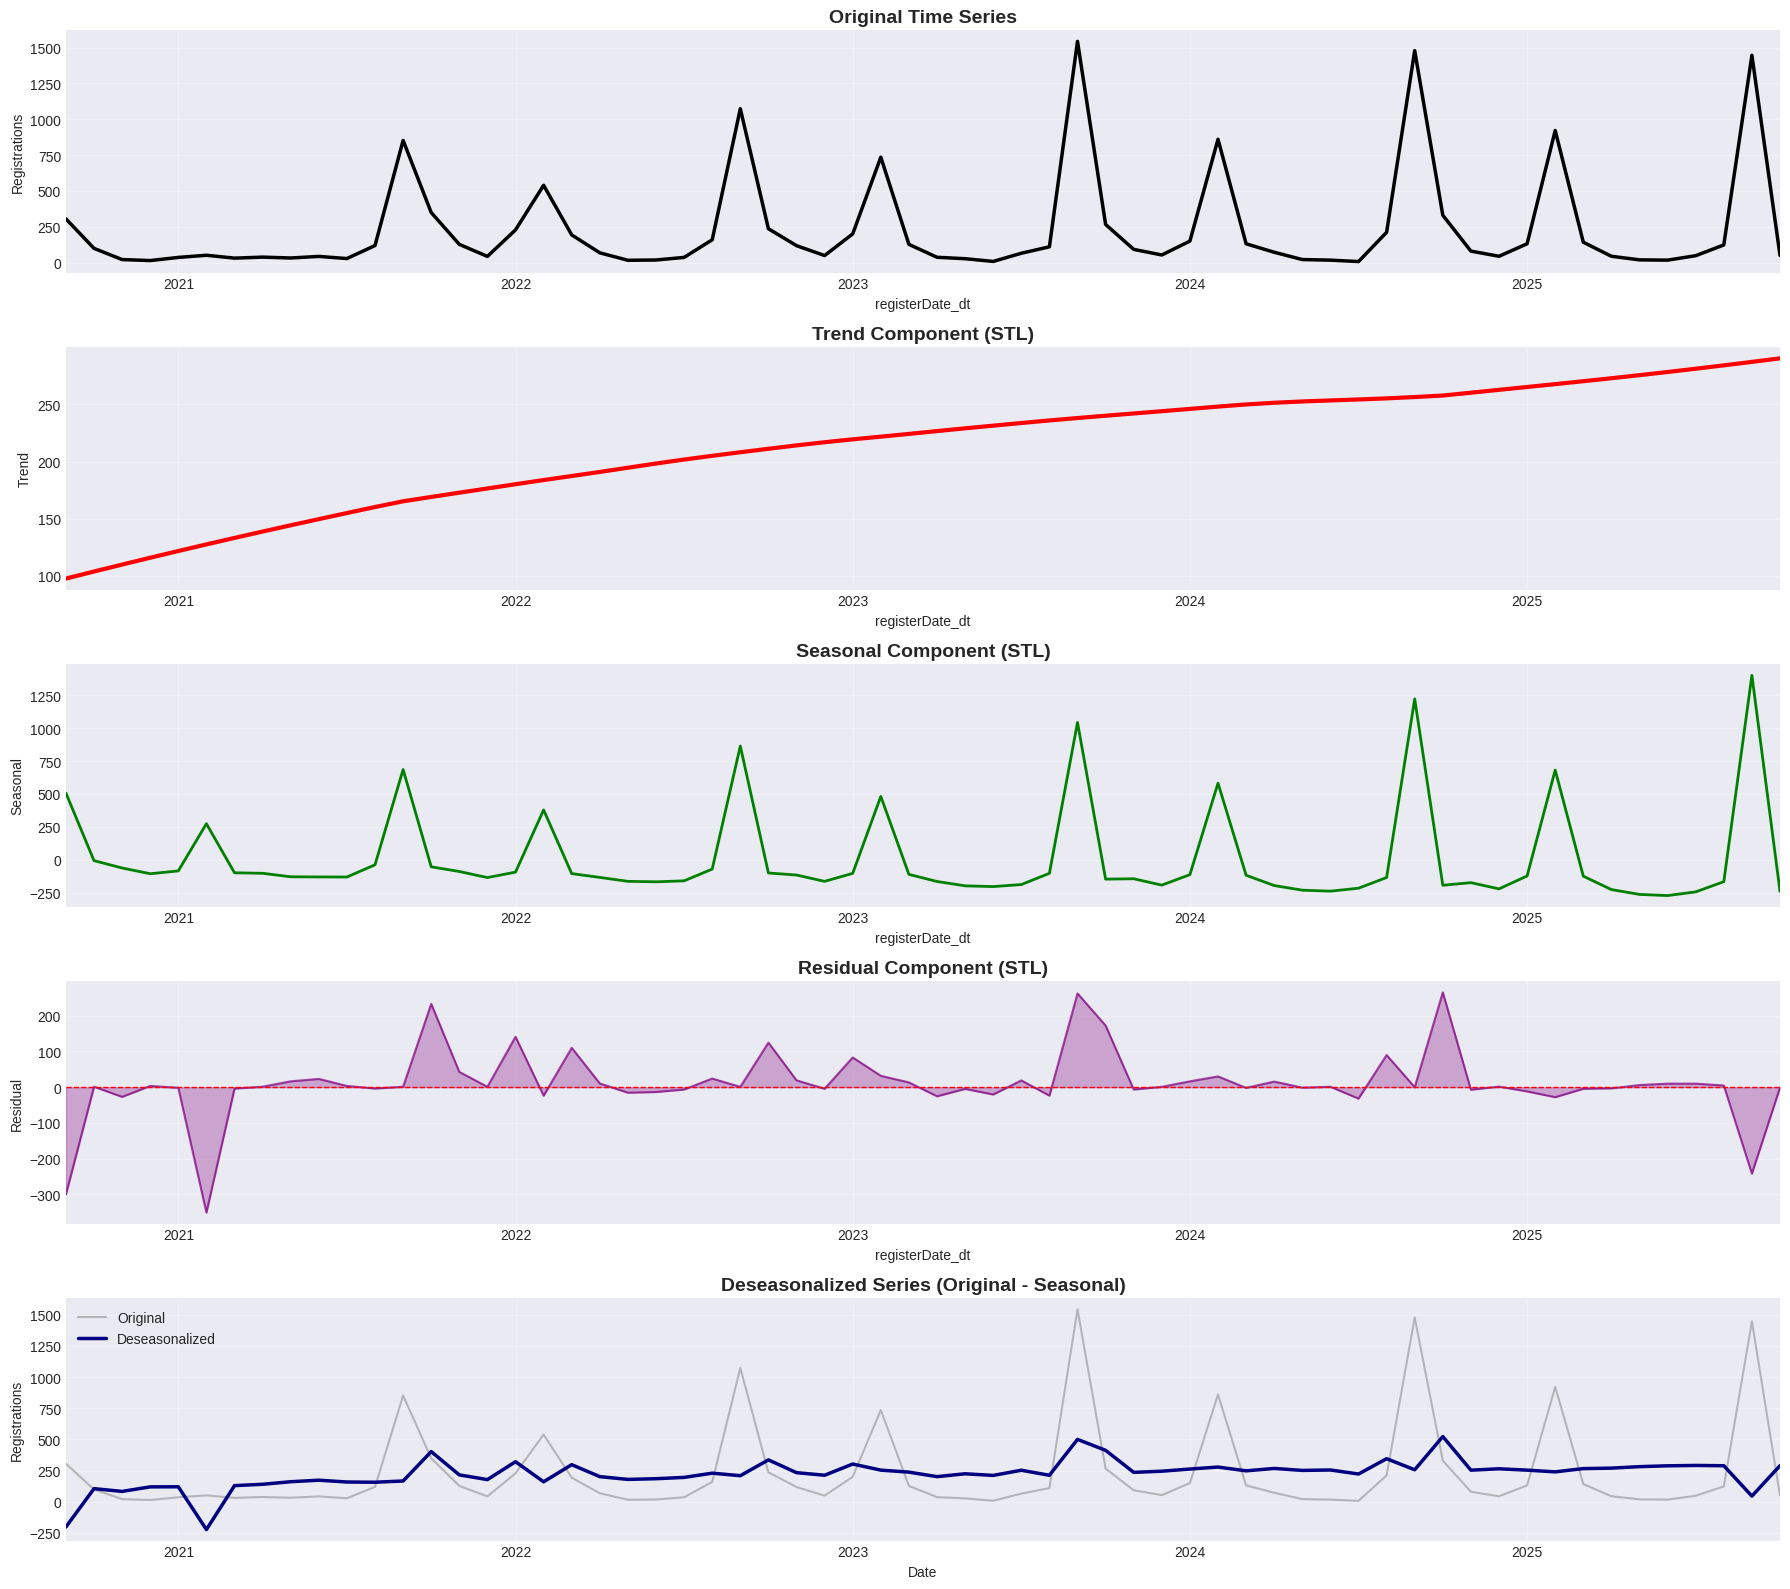

In [40]:
from statsmodels.tsa.seasonal import STL

stl = STL(monthly_complete, seasonal=13, trend=25, robust=True)  # seasonal=13 for monthly data
result = stl.fit()

trend = result.trend
seasonal = result.seasonal
residual = result.resid

fig, axes = plt.subplots(5, 1, figsize=(18, 16))

monthly_complete.plot(ax=axes[0], linewidth=2.5, color='black')
axes[0].set_title('Original Time Series', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Registrations')
axes[0].grid(alpha=0.3)

trend.plot(ax=axes[1], linewidth=3, color='red')
axes[1].set_title('Trend Component (STL)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Trend')
axes[1].grid(alpha=0.3)

seasonal.plot(ax=axes[2], linewidth=2, color='green')
axes[2].set_title('Seasonal Component (STL)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Seasonal')
axes[2].grid(alpha=0.3)

residual.plot(ax=axes[3], linewidth=1.5, color='purple', alpha=0.7)
axes[3].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[3].fill_between(residual.index, 0, residual.values, alpha=0.3, color='purple')
axes[3].set_title('Residual Component (STL)', fontsize=14, fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].grid(alpha=0.3)

# Deseasonalized series (Original - Seasonal)
deseasonalized = monthly_complete - seasonal
monthly_complete.plot(ax=axes[4], linewidth=1.5, alpha=0.5, label='Original', color='gray')
deseasonalized.plot(ax=axes[4], linewidth=2.5, label='Deseasonalized', color='navy')
axes[4].set_title('Deseasonalized Series (Original - Seasonal)', fontsize=14, fontweight='bold')
axes[4].set_ylabel('Registrations')
axes[4].set_xlabel('Date')
axes[4].legend()
axes[4].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/stl_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()

def calculate_strength(component, residual):
    return max(0, 1 - (residual.var() / (component + residual).var()))

trend_strength = calculate_strength(trend, residual)
seasonal_strength = calculate_strength(seasonal, residual)

The STL decomposition breaks down the series into three components:

**Trend**: Nearly linear growth from ~100 to ~300 monthly registrations between 2020-2025. 

**Seasonal**: The annual pattern is consistent, with September contributing +800 registrations above trend and summer months sitting around 0. The amplitude stays stable year after year, showing the academic calendar's predictable effect on registration timing.

**Residual**: Small fluctuations mostly within ±100 registrations, meaning the trend and seasonal components explain most of the variation. The larger spikes in late 2020/early 2021 likely reflect COVID-19 recovery, while the 2025 spike is an artifact of incomplete data.

**Deseasonalized series**: With seasonality removed, we see a clean upward trend with minimal noise. Growth is real and consistent, not just a result of changing seasonal patterns.

The lag plots reveal clear autocorrelation structure at annual intervals. **Lag 12** shows the strongest positive correlation (ρ=0.933), with points clustering tightly along a near-diagonal line—registrations in any given month strongly predict values exactly one year later. This annual memory extends to **lag 24** (ρ=0.880) and **lag 36** (ρ=0.806), confirming the series "remembers" its seasonal pattern for multiple years.

Short-term lags (1-3 months) show weak or negative correlations, reflecting rapid transitions between peak and trough months within each cycle. Mid-range lags (6, 9, 15, 18 months) display moderate negative correlations as they compare opposite phases of the annual cycle. The consistent pattern across all 12-month multiples indicates stable, predictable seasonality suitable for forecasting models.

### 5.4. Lag Plot Analysis

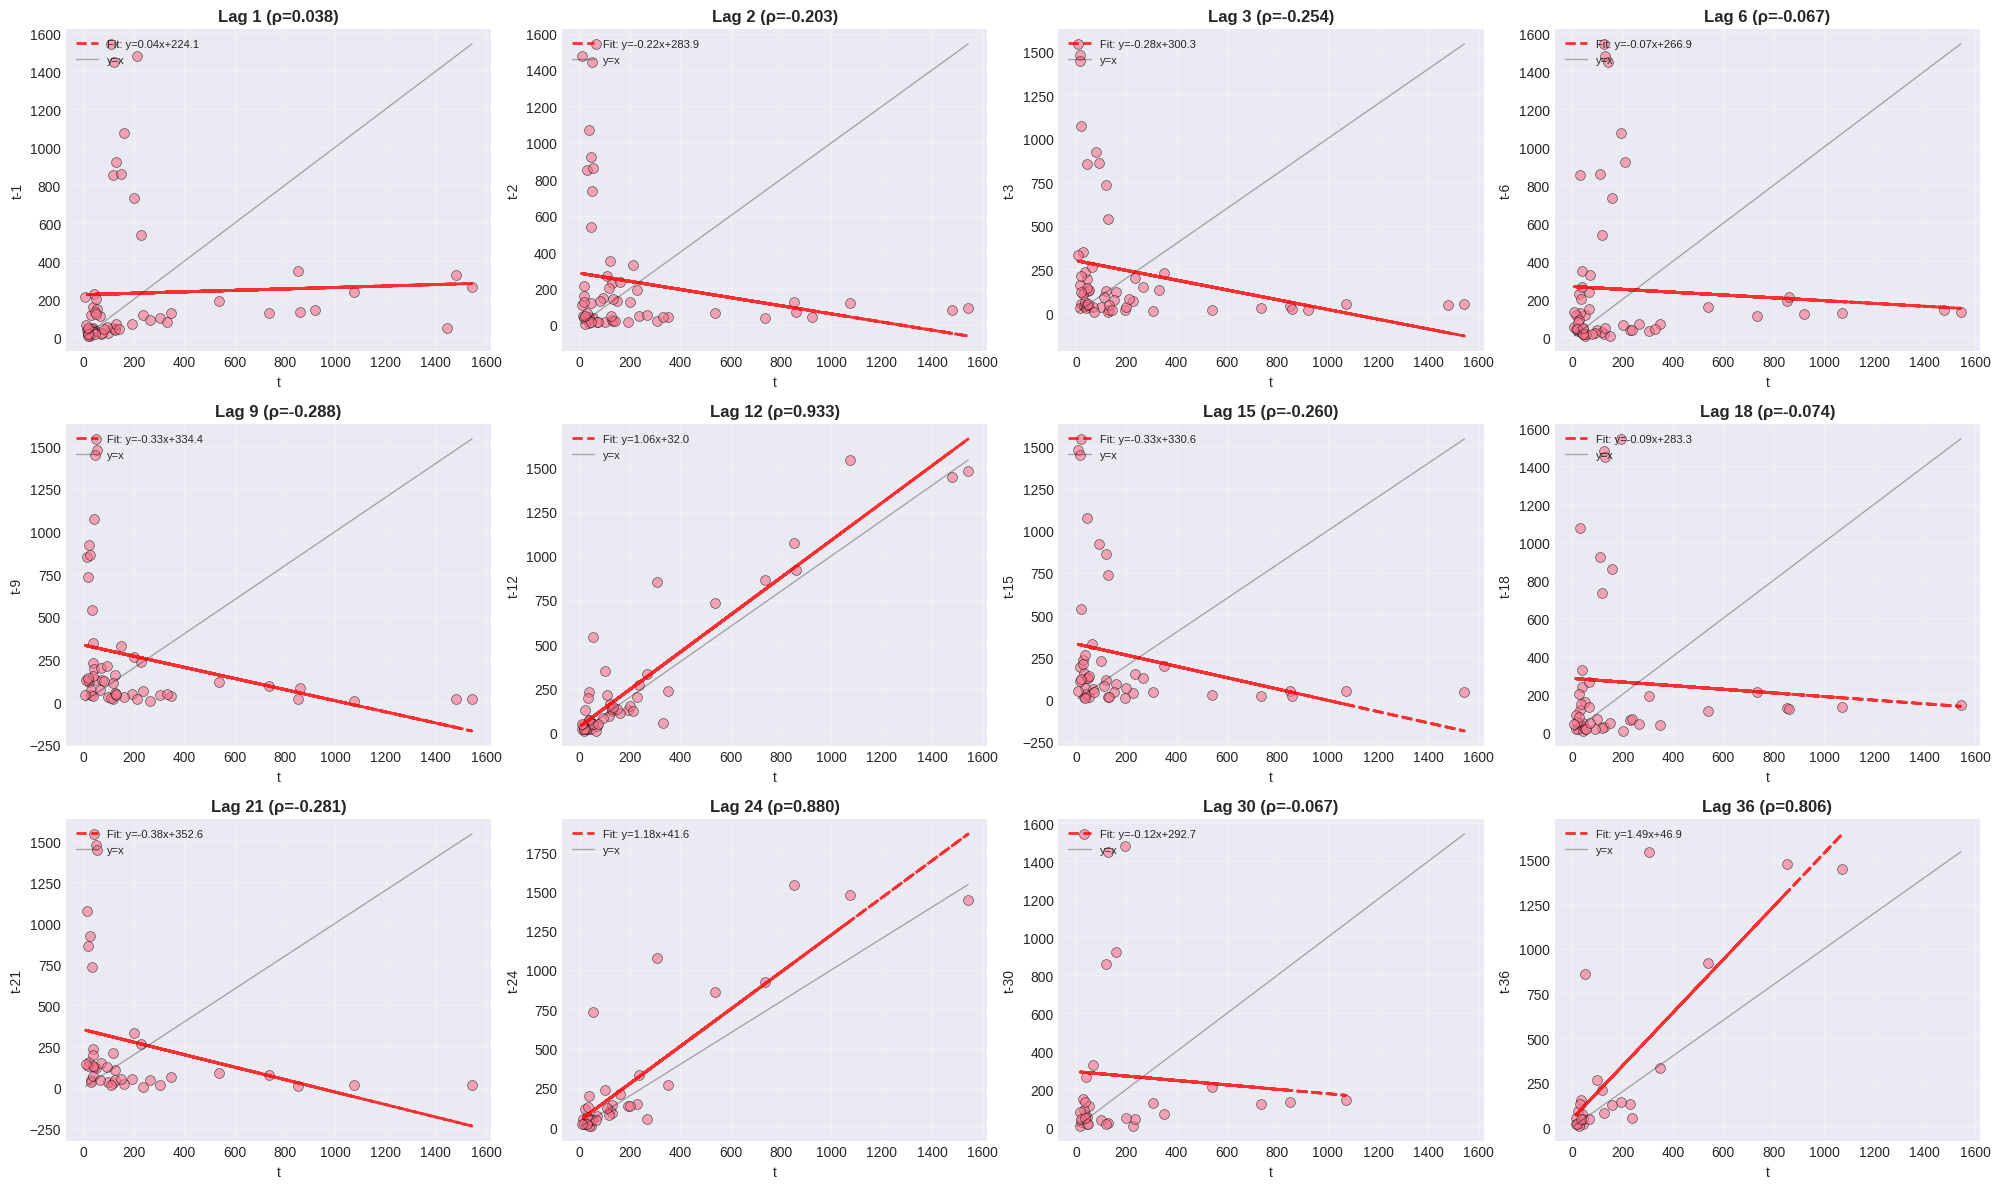

In [41]:
from pandas.plotting import lag_plot

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

lags_to_plot = [1, 2, 3, 6, 9, 12, 15, 18, 21, 24, 30, 36]

for i, lag in enumerate(lags_to_plot):
    ax = axes[i]
    
    y = monthly_complete.values[lag:]
    x = monthly_complete.values[:-lag]
    
    ax.scatter(x, y, alpha=0.6, s=50, edgecolors='black', linewidths=0.5)
    
    if len(x) > 1:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        ax.plot(x, p(x), "r--", linewidth=2, alpha=0.8, label=f'Fit: y={z[0]:.2f}x+{z[1]:.1f}')
    
    corr = monthly_complete.autocorr(lag=lag)
    
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, 'k-', alpha=0.3, linewidth=1, label='y=x')
    
    ax.set_title(f'Lag {lag} (ρ={corr:.3f})', fontsize=12, fontweight='bold')
    ax.set_xlabel(f't')
    ax.set_ylabel(f't-{lag}')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/lag_plots.png', dpi=300, bbox_inches='tight')
plt.show()

The scatter plots show three different timescales: **Lag 1** has essentially no correlation (ρ=0.038), **lag 6** is slightly negative (ρ=-0.067), while **lag 12** shows a near-perfect linear relationship (ρ=0.933). The color gradient reveals that recent years (yellow/green points) tend toward higher values, reflecting overall growth.

The ACF bar chart confirms what the lag plots suggest—significant spikes every 12 months (highlighted in blue), with most other lags showing weak or negative correlations. Almost all bars exceed the 95% confidence bounds (red dashed lines), meaning these correlations are statistically significant and not random noise.

**Lag 12** shows the strongest positive correlation (ρ=0.933), with points clustering tightly along a near-diagonal line—registrations in any given month strongly predict values exactly one year later. This annual pattern extends to **lag 24** (ρ=0.880) and **lag 36** (ρ=0.806), confirming the series keeps its seasonal pattern for multiple years.

Short-term lags (1-3 months) show weak or negative correlations, reflecting rapid transitions between peak and trough months within each cycle. Mid-range lags (6, 9, 15, 18 months) display moderate negative correlations as they compare opposite phases of the annual cycle. The consistent pattern across all 12-month multiples indicates stable, predictable seasonality suitable for forecasting models.


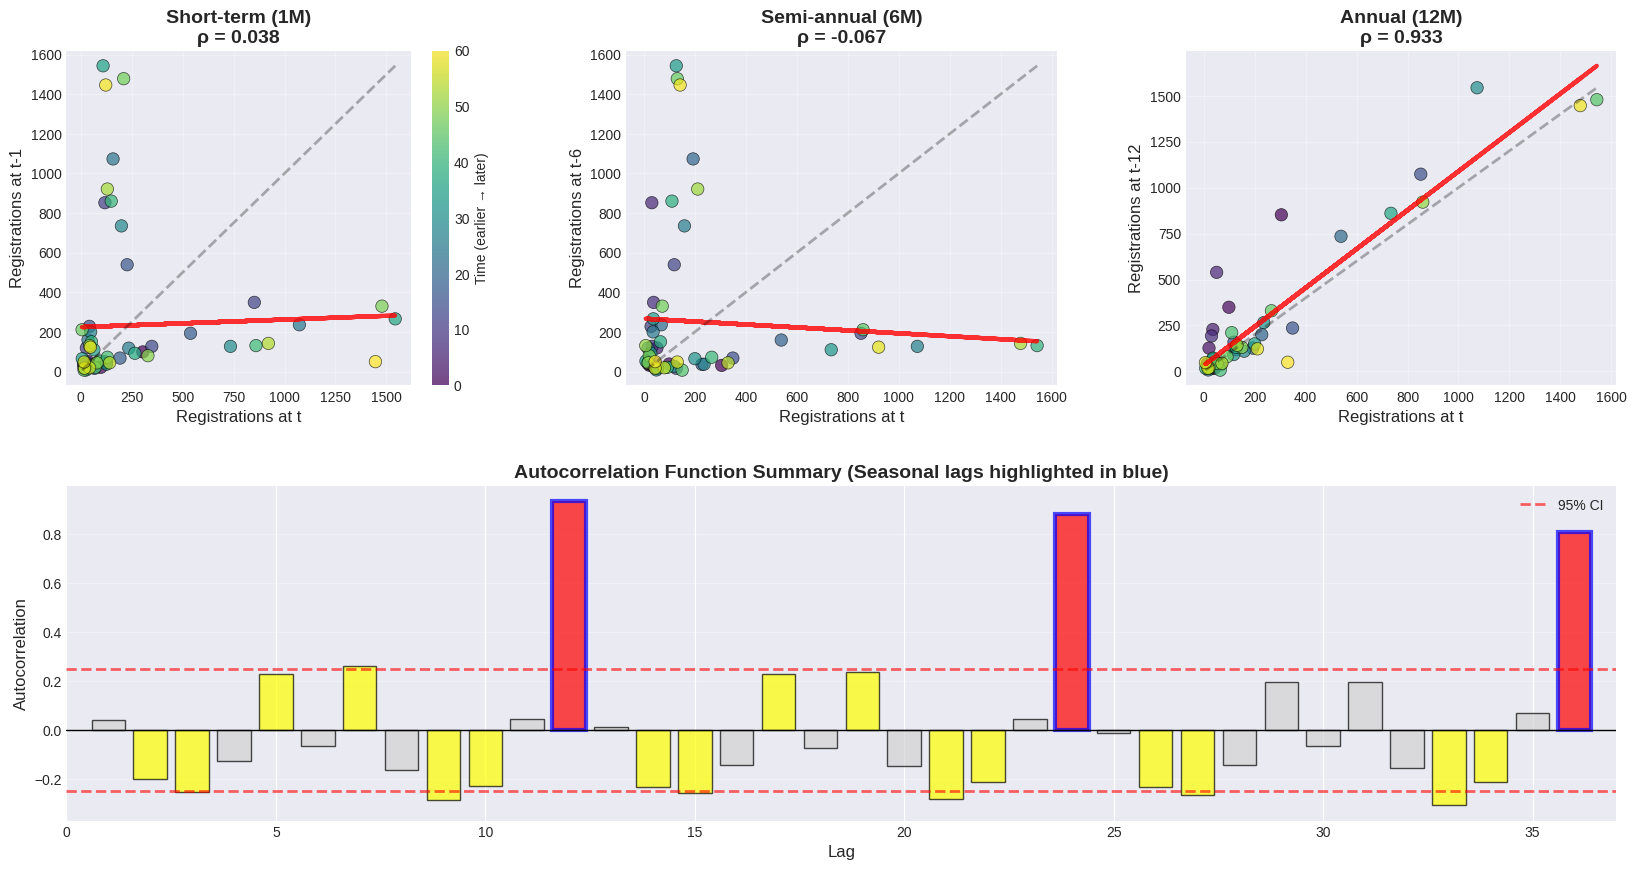

In [42]:
fig = plt.figure(figsize=(20, 10))
gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# Key seasonal lags: 1, 6, 12 (most important)
key_lags = [(1, 'Short-term (1M)'), (6, 'Semi-annual (6M)'), (12, 'Annual (12M)')]

for i, (lag, title) in enumerate(key_lags):
    ax = fig.add_subplot(gs[0, i])
    
    y = monthly_complete.values[lag:]
    x = monthly_complete.values[:-lag]
    
    colors = np.arange(len(x))
    scatter = ax.scatter(x, y, c=colors, cmap='viridis', alpha=0.7, s=80, edgecolors='black', linewidths=0.5)
    
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    ax.plot(x, p(x), "r-", linewidth=3, alpha=0.8)
    
    corr = monthly_complete.autocorr(lag=lag)
    
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=2)
    
    ax.set_title(f'{title}\nρ = {corr:.3f}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Registrations at t', fontsize=12)
    ax.set_ylabel(f'Registrations at t-{lag}', fontsize=12)
    ax.grid(alpha=0.3)
    
    if i == 0:
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Time (earlier → later)', fontsize=10)

ax = fig.add_subplot(gs[1, :])

max_lag = 36
correlations_all = [monthly_complete.autocorr(lag=lag) for lag in range(1, max_lag+1)]

colors_bar = ['red' if abs(c) > 0.6 else 'orange' if abs(c) > 0.4 else 'yellow' if abs(c) > 0.2 else 'lightgray' for c in correlations_all]
bars = ax.bar(range(1, max_lag+1), correlations_all, color=colors_bar, edgecolor='black', alpha=0.7)

seasonal_lags = [12, 24, 36]
for lag in seasonal_lags:
    if lag <= max_lag:
        bars[lag-1].set_edgecolor('blue')
        bars[lag-1].set_linewidth(3)

ax.axhline(y=0, color='black', linewidth=1)
ax.axhline(y=1.96/np.sqrt(len(monthly_complete)), color='red', linestyle='--', linewidth=2, label='95% CI', alpha=0.6)
ax.axhline(y=-1.96/np.sqrt(len(monthly_complete)), color='red', linestyle='--', linewidth=2, alpha=0.6)

ax.set_title('Autocorrelation Function Summary (Seasonal lags highlighted in blue)', fontsize=14, fontweight='bold')
ax.set_xlabel('Lag', fontsize=12)
ax.set_ylabel('Autocorrelation', fontsize=12)
ax.legend()
ax.grid(alpha=0.3, axis='y')
ax.set_xlim(0, max_lag+1)

plt.savefig('plots/lag_summary.png', dpi=300, bbox_inches='tight')
plt.show()
